# Kaggle API Setup

In [1]:
from google.colab import files
uploaded=files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
get_ipython().system('cp kaggle.json ~/.kaggle/')
get_ipython().system('chmod 600 ~/.kaggle/kaggle.json')

Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


# Download And Extract Dataset

In [2]:
get_ipython().system('pip install -q kaggle')
get_ipython().system('kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset')

import zipfile
zip_ref = zipfile.ZipFile('/content/microsoft-catsvsdogs-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
microsoft-catsvsdogs-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


# **Imports**

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

from sklearn.metrics import confusion_matrix, classification_report

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Data Cleaning

In [4]:
import os
from PIL import Image

folder = '/content/PetImages'
bad_files = 0

for subfolder in ['Cat', 'Dog']:
    path = os.path.join(folder, subfolder)
    for filename in os.listdir(path):
        filepath = os.path.join(path, filename)
        try:
            img = Image.open(filepath)
            img.verify()
        except Exception:
            os.remove(filepath)
            bad_files += 1

print(f"Removed {bad_files} corrupted files")

Removed 4 corrupted files


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [5]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Data Loading

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    '/content/PetImages',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    '/content/PetImages',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

print(train_data.class_indices)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
{'Cat': 0, 'Dog': 1}


# Custom CNN Architecture

In [7]:
model=Sequential()

model.add(Conv2D(32,(3,3),padding='valid',activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(256,(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.30))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile and train

In [8]:
early_stop=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history=model.fit(train_data,
          epochs=10,
          validation_data=val_data,
          callbacks=[early_stop])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 304s 454ms/step - accuracy: 0.6470 - loss: 0.6679 - val_accuracy: 0.7357 - val_loss: 0.5206
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 281s 449ms/step - accuracy: 0.7345 - loss: 0.5318 - val_accuracy: 0.7587 - val_loss: 0.4987
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 284s 455ms/step - accuracy: 0.7706 - loss: 0.4803 - val_accuracy: 0.8147 - val_loss: 0.4105
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 284s 455ms/step - accuracy: 0.8019 - loss: 0.4353 - val_accuracy: 0.8069 - val_loss: 0.4094
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 283s 453ms/step - accuracy: 0.8235 - loss: 0.3963 - val_accuracy: 0.8373 - val_loss: 0.3676
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 283s 453ms/step - accuracy: 0.8452 - loss: 0.3598 - val_accuracy: 0.8497 - val_loss: 0.3370
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 285s 456ms/step - accuracy: 0.8593 - loss: 0.3322 - val_accuracy: 0.8491 - val_loss: 0.3327
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 285s 456ms/step - accuracy: 0.8725 -

# Training Curves

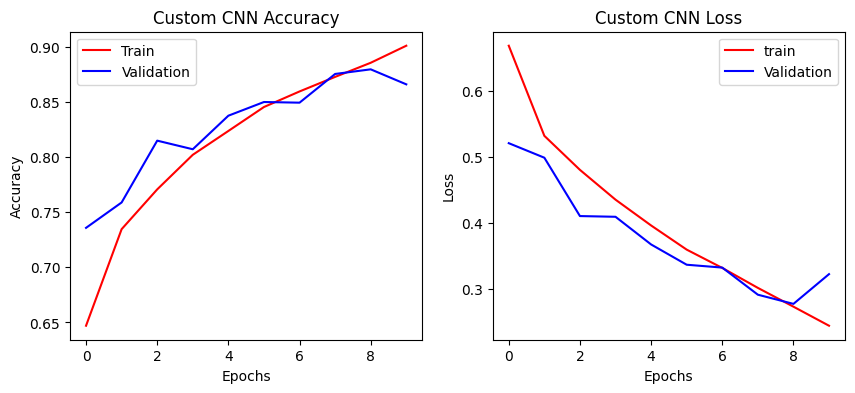

In [9]:
def plot_history(history, model_name="Model"):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], color='red', label='Train')
    plt.plot(history.history['val_accuracy'], color='blue', label='Validation')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], color='red', label='train')
    plt.plot(history.history['val_loss'], color='blue', label='Validation')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history,"Custom CNN")

# Confusion Matrix

157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step


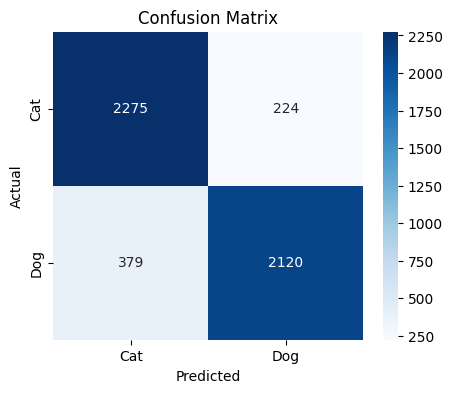

              precision    recall  f1-score   support

         Cat       0.86      0.91      0.88      2499
         Dog       0.90      0.85      0.88      2499

    accuracy                           0.88      4998
   macro avg       0.88      0.88      0.88      4998
weighted avg       0.88      0.88      0.88      4998



In [10]:
val_data.reset()
predictions = model.predict(val_data)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = val_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat','Dog'], yticklabels=['Cat','Dog'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(true_classes, predicted_classes, target_names=['Cat','Dog']))

# Prediction Function

In [11]:
def predict_image(img_path, model):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    label = "Dog" if prediction[0][0] > 0.5 else "Cat"
    print(f"Prediction: {label} ({prediction[0][0]:.4f})")

    plt.imshow(img)
    plt.axis('off')
    plt.title(label)
    plt.show()

    return label

# Test on Sample Image

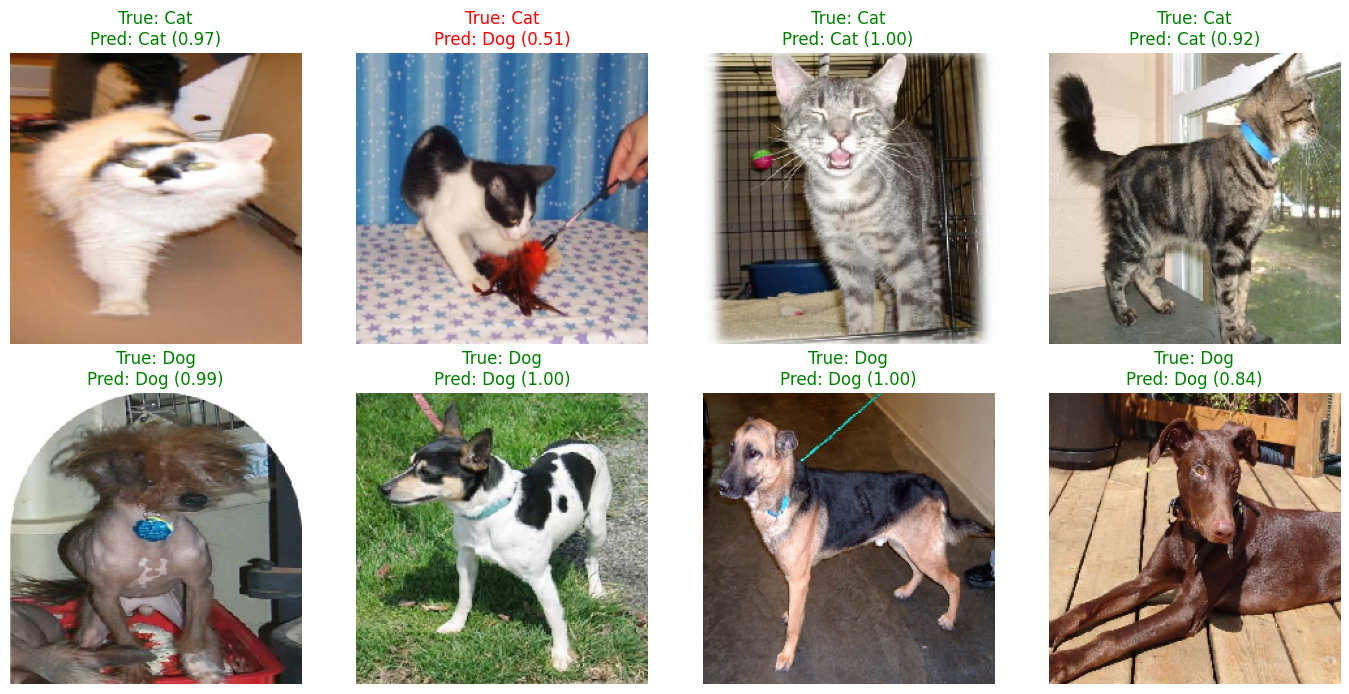

In [12]:
import random

cat_dir = '/content/PetImages/Cat'
dog_dir = '/content/PetImages/Dog'

cat_samples = random.sample(os.listdir(cat_dir), 4)
dog_samples = random.sample(os.listdir(dog_dir), 4)

sample_paths = [os.path.join(cat_dir, f) for f in cat_samples] + \
               [os.path.join(dog_dir, f) for f in dog_samples]
true_labels = ['Cat']*4 + ['Dog']*4

plt.figure(figsize=(14, 7))
for i, (path, true_label) in enumerate(zip(sample_paths, true_labels)):
    img = load_img(path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    pred_label = "Dog" if pred[0][0] > 0.5 else "Cat"
    confidence = pred[0][0] if pred_label == "Dog" else 1 - pred[0][0]

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.axis('off')
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})", color=color)

plt.tight_layout()
plt.show()

# Save Model

In [13]:
model.save('cat_dog_classifier.keras')
print("Model saved as cat_dog_classifier.keras")

Model saved as cat_dog_classifier.keras
